# Unidad 2.3 - LangGraph

**LangGraph** es un framework para construir aplicaciones **listas para producción** con LLMs, dándote control total sobre el flujo de tu agente.

**Temas cubiertos:**
1. **Bloques fundamentales** — Estado, Nodos y Aristas
2. **Primer grafo** — Sistema de clasificación de emails de Alfred
3. **Agente de análisis de documentos** — Patrón ReAct con visión

> ⚠️ Los ejemplos de este notebook requieren acceso a un LLM potente. Se recomienda usar la API de OpenAI (GPT-4o) por su compatibilidad con LangGraph.

> Alfred, el mayordomo, usa LangGraph para manejar emails de Mr. Wayne con flujos de decisión complejos. 🦇

## Instalación

In [1]:
%pip install langgraph langchain_openai langchain_core

Defaulting to user installation because normal site-packages is not writeable
  Using cached openai-2.37.0-py3-none-any.whl.metadata (31 kB)
  Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl.metadata (6.8 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached jiter-0.15.0-cp314-cp314-win_amd64.whl.metadata (5.3 kB)
  Using cached regex-2026.5.9-cp314-cp314-win_amd64.whl.metadata (41 kB)
Using cached openai-2.37.0-py3-none-any.whl (1.3 MB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached jiter-0.15.0-cp314-cp314-win_amd64.whl (197 kB)
Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl (918 kB)
Using cached regex-2026.5.9-cp314-cp314-win_amd64.whl (280 kB)

   --- ------------------------------------  1/11 [ormsgpack]
   -------------- -------------------------  4/11 [tiktoken]
   ------------------ ---------------------  5/11 [openai]
   ------------------ ---------------------  5/11 [openai]
   ------------------ --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Parte 1: Bloques Fundamentales de LangGraph

Una aplicación en LangGraph parte de un **punto de entrada** y el flujo pasa por nodos hasta alcanzar el `END`.

### 1. Estado (State)

El **Estado** es el concepto central en LangGraph. Representa toda la información que fluye por la aplicación. Debe contener todos los datos necesarios para el proceso de toma de decisiones.

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

print("Estado definido: contiene 'graph_state' como campo de texto")

Estado definido: contiene 'graph_state' como campo de texto


### 2. Nodos (Nodes)

Los **Nodos** son funciones Python que reciben el estado como entrada, realizan alguna operación y devuelven actualizaciones al estado.

In [3]:
def node_1(state):
    print("--- Nodo 1 ---")
    return {"graph_state": state['graph_state'] + " Yo soy"}

def node_2(state):
    print("--- Nodo 2 ---")
    return {"graph_state": state['graph_state'] + " ¡feliz!"}

def node_3(state):
    print("--- Nodo 3 ---")
    return {"graph_state": state['graph_state'] + " ¡triste!"}

print("Los nodos pueden contener: llamadas a LLMs, llamadas a herramientas, lógica condicional, intervención humana")

Los nodos pueden contener: llamadas a LLMs, llamadas a herramientas, lógica condicional, intervención humana


### 3. Aristas (Edges)

Las **Aristas** conectan nodos y definen los posibles caminos a través del grafo. Pueden ser directas o condicionales.

In [4]:
import random
from typing import Literal
from langgraph.graph import StateGraph, START, END

# Función de enrutamiento condicional
def decide_mood(state) -> Literal["node_2", "node_3"]:
    # Usamos el estado para decidir el siguiente nodo
    # Aquí hacemos una división 50/50 entre nodos 2 y 3
    if random.random() < 0.5:
        return "node_2"
    return "node_3"

# Construir el grafo
builder = StateGraph(State)

# Agregar nodos
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Aristas directas
builder.add_edge(START, "node_1")

# Arista condicional: decide_mood determina si ir a node_2 o node_3
builder.add_conditional_edges("node_1", decide_mood)

# Aristas finales hacia END
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Compilar el grafo
graph = builder.compile()

# Ejecutar el grafo
result = graph.invoke({"graph_state": "Hola, soy Alfred."})
print(f"Estado final: {result['graph_state']}")

--- Nodo 1 ---
--- Nodo 2 ---
Estado final: Hola, soy Alfred. Yo soy ¡feliz!


---
## Parte 2: Primer Grafo — Sistema de Clasificación de Emails de Alfred

Alfred necesita procesar los emails de Mr. Wayne:
1. Leer los emails entrantes
2. Clasificarlos como spam o legítimos
3. Redactar una respuesta preliminar para los legítimos
4. Notificar a Mr. Wayne cuando son legítimos

### Paso 1: Configuración del entorno

In [5]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Usa la variable de entorno OPENAI_API_KEY si está disponible
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = "tu-api-key-aquí"

print(f"API key configurada: {'✓ desde entorno' if os.environ.get('OPENAI_API_KEY', '').startswith('sk-') else '⚠ placeholder (configura OPENAI_API_KEY)'}")

API key configurada: ⚠ placeholder (configura OPENAI_API_KEY)


### Paso 2: Definir el Estado del Email

In [6]:
class EmailState(TypedDict):
    # El email que se procesa
    email: Dict[str, Any]            # Contiene subject, sender, body

    # Categoría del email (inquiry, complaint, etc.)
    email_category: Optional[str]

    # Razón por la que fue marcado como spam
    spam_reason: Optional[str]

    # Análisis y decisiones
    is_spam: Optional[bool]

    # Generación de respuesta
    email_draft: Optional[str]

    # Metadatos de procesamiento
    messages: List[Dict[str, Any]]   # Historial de conversación con el LLM

print("Estado de email definido con 6 campos")

Estado de email definido con 6 campos


### Paso 3: Definir los Nodos

In [7]:
# Inicializar el LLM
model = ChatOpenAI(temperature=0)

def read_email(state: EmailState):
    """Alfred lee y registra el email entrante."""
    email = state["email"]
    print(f"Alfred está procesando un email de {email['sender']} con asunto: {email['subject']}")
    return {}

def classify_email(state: EmailState):
    """Alfred usa un LLM para determinar si el email es spam o legítimo."""
    email = state["email"]

    prompt = f"""
    Como Alfred el mayordomo, analiza este email y determina si es spam o legítimo.

    Email:
    De: {email['sender']}
    Asunto: {email['subject']}
    Cuerpo: {email['body']}

    Primero, determina si este email es spam. Si lo es, explica por qué.
    Si es legítimo, categorízalo (inquiry, complaint, thank you, request, information).
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    response_text = response.content.lower()

    is_spam = "spam" in response_text and "not spam" not in response_text

    spam_reason = None
    if is_spam and "reason:" in response_text:
        spam_reason = response_text.split("reason:")[1].strip()

    email_category = None
    if not is_spam:
        categories = ["inquiry", "complaint", "thank you", "request", "information"]
        for category in categories:
            if category in response_text:
                email_category = category
                break

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """Alfred descarta el email de spam con una nota."""
    print(f"Alfred ha marcado el email como spam. Razón: {state['spam_reason']}")
    print("El email ha sido movido a la carpeta de spam.")
    return {}

def draft_response(state: EmailState):
    """Alfred redacta una respuesta preliminar para emails legítimos."""
    email = state["email"]
    category = state["email_category"] or "general"

    prompt = f"""
    Como Alfred el mayordomo, redacta una respuesta preliminar educada para este email.

    Email:
    De: {email['sender']}
    Asunto: {email['subject']}
    Cuerpo: {email['body']}

    Este email ha sido categorizado como: {category}

    Redacta una respuesta breve y profesional que Mr. Wayne pueda revisar y personalizar antes de enviar.
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_wayne(state: EmailState):
    """Alfred notifica a Mr. Wayne sobre el email y presenta el borrador."""
    email = state["email"]

    print("\n" + "="*50)
    print(f"Señor, ha recibido un email de {email['sender']}.")
    print(f"Asunto: {email['subject']}")
    print(f"Categoría: {state['email_category']}")
    print("\nHe preparado un borrador de respuesta para su revisión:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    return {}

print("Nodos del grafo definidos")

Nodos del grafo definidos


### Paso 4: Lógica de enrutamiento

In [8]:
def route_email(state: EmailState) -> str:
    """Determina el siguiente paso basado en la clasificación de spam."""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

print("Función de enrutamiento definida")

Función de enrutamiento definida


### Paso 5: Construir y compilar el grafo

In [9]:
# Crear el grafo
email_graph = StateGraph(EmailState)

# Agregar nodos
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_wayne", notify_mr_wayne)

# Definir aristas — el flujo del grafo
email_graph.add_edge(START, "read_email")
email_graph.add_edge("read_email", "classify_email")

# Arista condicional desde classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

# Aristas finales
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_wayne")
email_graph.add_edge("notify_mr_wayne", END)

# Compilar el grafo
compiled_graph = email_graph.compile()

print("Grafo compilado exitosamente")

Grafo compilado exitosamente


### Paso 6: Visualizar el grafo

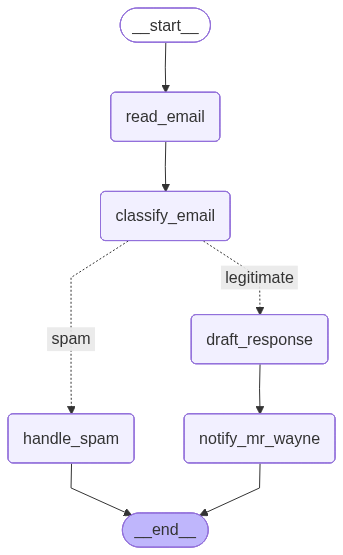

In [10]:
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualización no disponible: {e}")
    print(compiled_graph.get_graph().draw_mermaid())

### Paso 7: Probar el grafo

In [11]:
# Email legítimo de ejemplo
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Pregunta sobre sus servicios de consultoría",
    "body": "Estimado Sr. Wayne, un colega me recomendó contactarle y me interesa saber más sobre sus servicios de consultoría. ¿Podríamos agendar una llamada la próxima semana? Atentamente, John Smith"
}

# Email de spam de ejemplo
spam_email = {
    "sender": "winner@loteria-internacional.com",
    "subject": "¡HAS GANADO $5,000,000!!!",
    "body": "FELICITACIONES! Has sido seleccionado como ganador de nuestra lotería internacional. Para reclamar tu premio de $5,000,000, envíanos tus datos bancarios y una tarifa de procesamiento de $100."
}

# Procesar el email legítimo
print("\n" + "#"*60)
print("PROCESANDO EMAIL LEGÍTIMO...")
print("#"*60)
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


############################################################
PROCESANDO EMAIL LEGÍTIMO...
############################################################
Alfred está procesando un email de john.smith@example.com con asunto: Pregunta sobre sus servicios de consultoría


UnicodeEncodeError: 'ascii' codec can't encode character '\xed' in position 21: ordinal not in range(128)

In [12]:
# Procesar el email de spam
print("\n" + "#"*60)
print("PROCESANDO EMAIL DE SPAM...")
print("#"*60)
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


############################################################
PROCESANDO EMAIL DE SPAM...
############################################################
Alfred está procesando un email de winner@loteria-internacional.com con asunto: ¡HAS GANADO $5,000,000!!!


UnicodeEncodeError: 'ascii' codec can't encode character '\xed' in position 21: ordinal not in range(128)

In [13]:
%pip install -q langfuse langchain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Parte 3: Agente de Análisis de Documentos — Patrón ReAct

Alfred usa el patrón **ReAct (Reason-Act-Observe)** para analizar documentos de Mr. Wayne:
1. **Razona** sobre los documentos y solicitudes
2. **Actúa** usando herramientas apropiadas
3. **Observa** los resultados
4. **Repite** hasta completar la tarea

### Configuración del entorno y herramientas

In [14]:
vision_llm = ChatOpenAI(model="gpt-4o")

def extract_text(img_path: str) -> str:
    """
    Extrae texto de un archivo de imagen usando un modelo multimodal.

    Mr. Wayne frecuentemente deja notas con su régimen de entrenamiento o planes de comidas.
    Esto permite analizar el contenido correctamente.
    """
    all_text = ""
    try:
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": "Extrae todo el texto de esta imagen. Devuelve solo el texto extraído, sin explicaciones.",
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        response = vision_llm.invoke(message)
        all_text += response.content + "\n\n"
        return all_text.strip()
    except Exception as e:
        error_msg = f"Error al extraer texto: {str(e)}"
        print(error_msg)
        return ""

def divide(a: int, b: int) -> float:
    """Divide a entre b — para los cálculos ocasionales de Mr. Wayne."""
    return a / b

# Equipar al mayordomo con herramientas
tools = [divide, extract_text]

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

print("Herramientas configuradas: extract_text y divide")

Herramientas configuradas: extract_text y divide


### Definir el nodo asistente y construir el grafo ReAct

In [15]:
def assistant(state: AgentState):
    textual_description_of_tool = """
extract_text(img_path: str) -> str:
    Extrae texto de un archivo de imagen usando un modelo multimodal.
    Args:
        img_path: Ruta local del archivo de imagen (strings).
    Returns:
        Una cadena con el texto extraído de la imagen.

divide(a: int, b: int) -> float:
    Divide a entre b.
"""
    image = state["input_file"]
    sys_msg = SystemMessage(
        content=f"Eres Alfred, el mayordomo de Mr. Wayne y Batman. Puedes analizar documentos y realizar cálculos con las herramientas disponibles:\n{textual_description_of_tool}\nTienes acceso a imágenes opcionales. La imagen actualmente cargada es: {image}"
    )

    return {
        "messages": [llm_with_tools.invoke([sys_msg] + state["messages"])],
        "input_file": state["input_file"]
    }

# Construir el grafo ReAct
builder = StateGraph(AgentState)

# Nodos
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Aristas
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,  # Si el último mensaje requiere herramienta → tools, si no → END
)
builder.add_edge("tools", "assistant")  # Las herramientas siempre regresan al asistente

react_graph = builder.compile()

try:
    display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Visualización no disponible: {e}")

NameError: name 'AgentState' is not defined

### Ejemplo 1: Cálculos simples con el agente ReAct

In [16]:
messages = [HumanMessage(content="Divide 6790 entre 5")]
result = react_graph.invoke({"messages": messages, "input_file": None})

print("\n--- Conversación ---")
for m in result['messages']:
    m.pretty_print()

NameError: name 'react_graph' is not defined

### Ejemplo 2: Análisis de documento con visión

> Para este ejemplo necesitas una imagen real. Puedes crear una imagen PNG de prueba con texto.
> El agente usará la herramienta `extract_text` para leer el contenido.

In [17]:
# Ejemplo de análisis de documento de entrenamiento
# Asegúrate de tener una imagen disponible en la ruta especificada

# Para pruebas, puedes crear una imagen de texto simple:
# from PIL import Image as PILImage, ImageDraw
# img = PILImage.new('RGB', (400, 200), color='white')
# draw = ImageDraw.Draw(img)
# draw.text((10, 10), "Menú de entrenamiento Batman:\n- Proteína: pollo y arroz\n- Ejercicio: 100 flexiones", fill='black')
# img.save('batman_training.png')

# Descomentar para usar con una imagen real:
# messages = [HumanMessage(content="Según las notas de Mr. Wayne en las imágenes proporcionadas, ¿qué artículos debo comprar para el menú de la cena?")]
# result = react_graph.invoke({"messages": messages, "input_file": "batman_training.png"})
# for m in result['messages']:
#     m.pretty_print()

print("Para usar el análisis de documentos, proporciona la ruta de una imagen PNG o PDF.")

Para usar el análisis de documentos, proporciona la ruta de una imagen PNG o PDF.


---
## Resumen

| Concepto | Descripción |
|---|---|
| **State** | Datos que fluyen por el grafo — definido por el usuario con TypedDict |
| **Node** | Función Python que lee el estado y devuelve actualizaciones |
| **Edge** | Conexión directa entre nodos |
| **Conditional Edge** | Arista que decide el camino según el estado actual |
| **START / END** | Nodos especiales de LangGraph para entrada y salida |
| **tools_condition** | Función prebuilt que enruta si el modelo hace una llamada a herramienta |
| **add_messages** | Operador que acumula mensajes en lugar de sobrescribirlos |
| **Patrón ReAct** | Reason → Act → Observe: el bucle base de los agentes LangGraph |

**Recursos:**
- [Documentación oficial de LangGraph](https://langchain-ai.github.io/langgraph/)
- [Curso de LangChain Academy - Intro to LangGraph](https://academy.langchain.com/courses/intro-to-langgraph)
- [Langfuse para observabilidad](https://langfuse.com/)